# Hyperparameter Tuning and Model Optimization

## The Three Search Paradigms

## Grid Search vs. Random Search: An Empirical Comparison

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from scipy.stats import randint, loguniform, uniform

# ── Re-create Adult Income dataset and pipeline ───────────────────────────
adult_url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases"
    "/adult/adult.data"
)
adult_cols = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "income"
]
df_adult = pd.read_csv(adult_url, names=adult_cols,
                       na_values=" ?", skipinitialspace=True)
df_adult["income"] = (df_adult["income"].str.strip() == ">50K").astype(int)
df_adult = df_adult.dropna()

cat_cols_adult = [
    "workclass", "education", "marital_status", "occupation",
    "relationship", "race", "sex", "native_country"
]
num_cols_adult = [
    "age", "fnlwgt", "education_num", "capital_gain",
    "capital_loss", "hours_per_week"
]

X_adult = df_adult[num_cols_adult + cat_cols_adult]
y_adult = df_adult["income"]
X_atr, X_ate, y_atr, y_ate = train_test_split(
    X_adult, y_adult,
    test_size=0.20, stratify=y_adult, random_state=RANDOM_SEED
)

def adult_preprocessor():
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
                        handle_unknown="use_encoded_value",
                        unknown_value=-1))
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_cols_adult),
        ("cat", cat_pipe, cat_cols_adult)
    ])

def make_adult_pipe(clf):
    return Pipeline([
        ("preprocessor", adult_preprocessor()),
        ("clf",           clf)
    ])

# ── Fixed compute budget: 60 model evaluations, 5-fold CV ─────────────────
BUDGET = 60
cv_budget = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Grid search: 3 x 4 x 5 = 60 combinations
param_grid_gs = {
    "clf__n_estimators":   [100, 200, 300],
    "clf__max_depth":      [3, 4, 5, 6],
    "clf__learning_rate":  [0.01, 0.05, 0.1, 0.15, 0.2],
}

gs_grid = GridSearchCV(
    make_adult_pipe(
        GradientBoostingClassifier(subsample=0.8, random_state=RANDOM_SEED)
    ),
    param_grid_gs,
    cv=cv_budget, scoring="roc_auc",
    n_jobs=-1, refit=False
)
gs_grid.fit(X_atr, y_atr)

# Random search: 60 draws from continuous distributions
param_dist_rs = {
    "clf__n_estimators":     randint(50, 500),
    "clf__max_depth":        randint(2, 8),
    "clf__learning_rate":    loguniform(1e-3, 0.5),
    "clf__min_samples_leaf": randint(1, 30),
    "clf__subsample":        uniform(0.6, 0.4),
}

gs_rand = RandomizedSearchCV(
    make_adult_pipe(
        GradientBoostingClassifier(random_state=RANDOM_SEED)
    ),
    param_dist_rs,
    n_iter=BUDGET,
    cv=cv_budget, scoring="roc_auc",
    random_state=RANDOM_SEED, n_jobs=-1, refit=False
)
gs_rand.fit(X_atr, y_atr)

grid_scores = gs_grid.cv_results_["mean_test_score"]
rand_scores  = gs_rand.cv_results_["mean_test_score"]

print(f"Grid Search  — Best CV AUC-ROC : {grid_scores.max():.4f}")
print(f"Random Search — Best CV AUC-ROC : {rand_scores.max():.4f}")
print(f"Best grid params  : {gs_grid.best_params_}")
print(f"Best random params: {gs_rand.best_params_}")

Grid Search  — Best CV AUC-ROC : 0.9261
Random Search — Best CV AUC-ROC : 0.9268
Best grid params  : {'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__n_estimators': 300}
Best random params: {'clf__learning_rate': np.float64(0.04348777880861619), 'clf__max_depth': 6, 'clf__min_samples_leaf': 9, 'clf__n_estimators': 206, 'clf__subsample': np.float64(0.9208787923016158)}


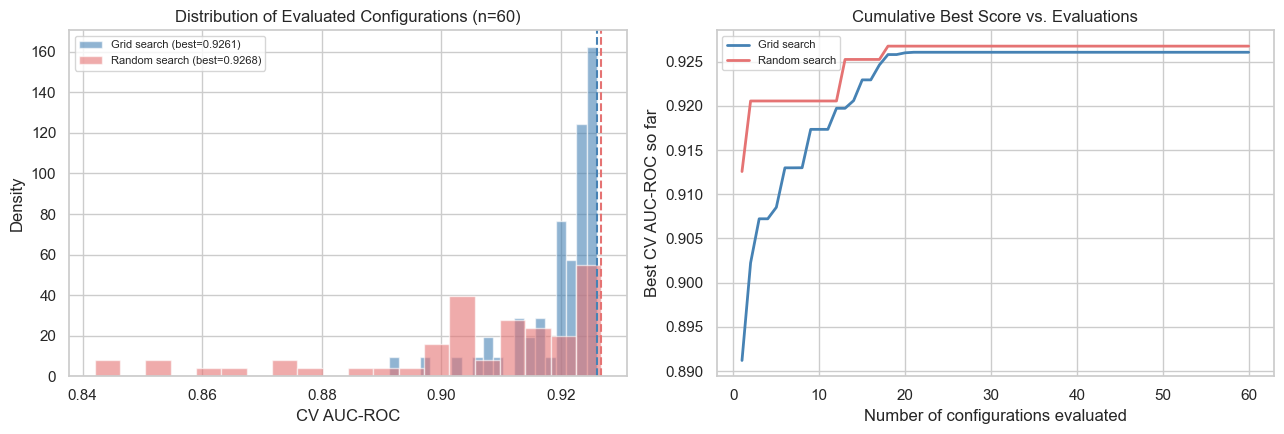

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel 1: distribution of evaluated CV scores
axes[0].hist(grid_scores, bins=20, alpha=0.6, color="steelblue",
             density=True, label=f"Grid search (best={grid_scores.max():.4f})")
axes[0].hist(rand_scores,  bins=20, alpha=0.6, color="#E57373",
             density=True, label=f"Random search (best={rand_scores.max():.4f})")
axes[0].axvline(grid_scores.max(), color="steelblue", lw=1.5, linestyle="--")
axes[0].axvline(rand_scores.max(),  color="#E57373",   lw=1.5, linestyle="--")
axes[0].set_xlabel("CV AUC-ROC")
axes[0].set_ylabel("Density")
axes[0].set_title("Distribution of Evaluated Configurations (n=60)")
axes[0].legend(fontsize=8)

# Panel 2: cumulative best score vs. evaluations
for scores, color, label in [
    (grid_scores, "steelblue", "Grid search"),
    (rand_scores,  "#E57373",   "Random search"),
]:
    cumulative_best = np.maximum.accumulate(scores)
    axes[1].plot(range(1, len(scores) + 1), cumulative_best,
                 lw=2, color=color, label=label)

axes[1].set_xlabel("Number of configurations evaluated")
axes[1].set_ylabel("Best CV AUC-ROC so far")
axes[1].set_title("Cumulative Best Score vs. Evaluations")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "ch16_gridsearch_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Bayesian Optimisation

### The Surrogate Model Approach

In [8]:
# ── Bayesian Optimisation with scikit-optimize ────────────────────────────
# pip install scikit-optimize
from skopt import BayesSearchCV
from skopt.space import Real, Integer

search_space = {
    "clf__n_estimators":     Integer(50, 500),
    "clf__max_depth":        Integer(2, 8),
    "clf__learning_rate":    Real(1e-3, 0.5, prior="log-uniform"),
    "clf__min_samples_leaf": Integer(1, 30),
    "clf__subsample":        Real(0.6, 1.0),
}

bayes_search = BayesSearchCV(
    make_adult_pipe(
        GradientBoostingClassifier(random_state=RANDOM_SEED)
    ),
    search_space,
    n_iter=BUDGET,
    cv=cv_budget,
    scoring="roc_auc",
    random_state=RANDOM_SEED,
    n_jobs=1,   # Bayesian search is sequential
    refit=False
)
bayes_search.fit(X_atr, y_atr)

bayes_scores = bayes_search.cv_results_["mean_test_score"]

print(f"Bayesian Optimisation — Best CV AUC-ROC : {bayes_scores.max():.4f}")
print(f"Best Bayesian params: {bayes_search.best_params_}")

Bayesian Optimisation — Best CV AUC-ROC : 0.9276
Best Bayesian params: OrderedDict({'clf__learning_rate': 0.059489699431535564, 'clf__max_depth': 4, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 369, 'clf__subsample': 1.0})


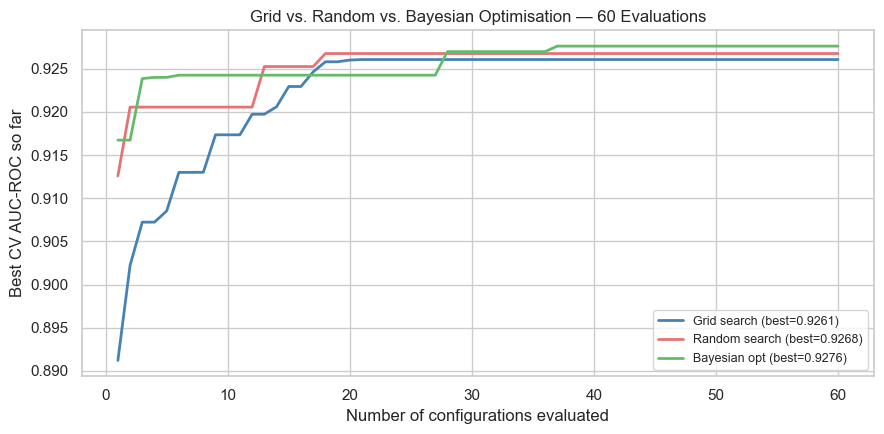

In [9]:
# ── Three-way comparison: cumulative best score ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))

for scores, color, label in [
    (grid_scores,  "steelblue", f"Grid search (best={grid_scores.max():.4f})"),
    (rand_scores,   "#E57373",   f"Random search (best={rand_scores.max():.4f})"),
    (bayes_scores,  "#66BB6A",   f"Bayesian opt (best={bayes_scores.max():.4f})"),
]:
    cumulative_best = np.maximum.accumulate(scores)
    ax.plot(range(1, len(scores) + 1), cumulative_best,
            lw=2, color=color, label=label)

ax.set_xlabel("Number of configurations evaluated")
ax.set_ylabel("Best CV AUC-ROC so far")
ax.set_title("Grid vs. Random vs. Bayesian Optimisation — 60 Evaluations")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / "ch16_bayes_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Practical Tuning Strategies and Compute Budgets

### Coarse-to-Fine Tuning

In [10]:
# ── Phase 1: broad random search ─────────────────────────────────────────
phase1_dist = {
    "clf__n_estimators":  randint(50, 600),
    "clf__max_depth":     randint(2, 10),
    "clf__learning_rate": loguniform(5e-4, 0.5),
    "clf__subsample":     uniform(0.5, 0.5),
}

gs_phase1 = RandomizedSearchCV(
    make_adult_pipe(
        GradientBoostingClassifier(random_state=RANDOM_SEED)
    ),
    phase1_dist,
    n_iter=100,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring="roc_auc",
    random_state=RANDOM_SEED, n_jobs=-1, refit=False
)
gs_phase1.fit(X_atr, y_atr)

# Identify top-10% configurations
phase1_df = pd.DataFrame(gs_phase1.cv_results_)
top_configs = phase1_df.nlargest(10, "mean_test_score")
print("Phase 1 — Top 10 configurations:")
print(top_configs[["param_clf__learning_rate", "param_clf__max_depth",
                    "param_clf__n_estimators", "mean_test_score"]].to_string())

# ── Phase 2: fine grid around promising region ────────────────────────────
phase2_grid = {
    "clf__learning_rate": [0.06, 0.08, 0.10, 0.12],
    "clf__max_depth":     [3, 4, 5],
    "clf__n_estimators":  [300, 400, 500],
    "clf__subsample":     [0.7, 0.8, 0.9],
}

gs_phase2 = GridSearchCV(
    make_adult_pipe(
        GradientBoostingClassifier(random_state=RANDOM_SEED)
    ),
    phase2_grid,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED),
    scoring="roc_auc",
    n_jobs=-1, refit=True
)
gs_phase2.fit(X_atr, y_atr)

print(f"\nPhase 2 — Best CV AUC: {gs_phase2.best_score_:.4f}")
print(f"Best params: {gs_phase2.best_params_}")

Phase 1 — Top 10 configurations:
    param_clf__learning_rate  param_clf__max_depth  param_clf__n_estimators  mean_test_score
93                  0.064557                     5                      267         0.926341
8                   0.035820                     5                      293         0.925956
95                  0.044493                     3                      571         0.925854
12                  0.056074                     5                      558         0.925724
15                  0.105771                     3                      251         0.925611
60                  0.016804                     7                      424         0.925411
75                  0.038252                     5                      370         0.925378
61                  0.029416                     7                      414         0.925098
56                  0.048919                     6                      387         0.924753
40                  0.068514         

### Parallelisation and Early Stopping

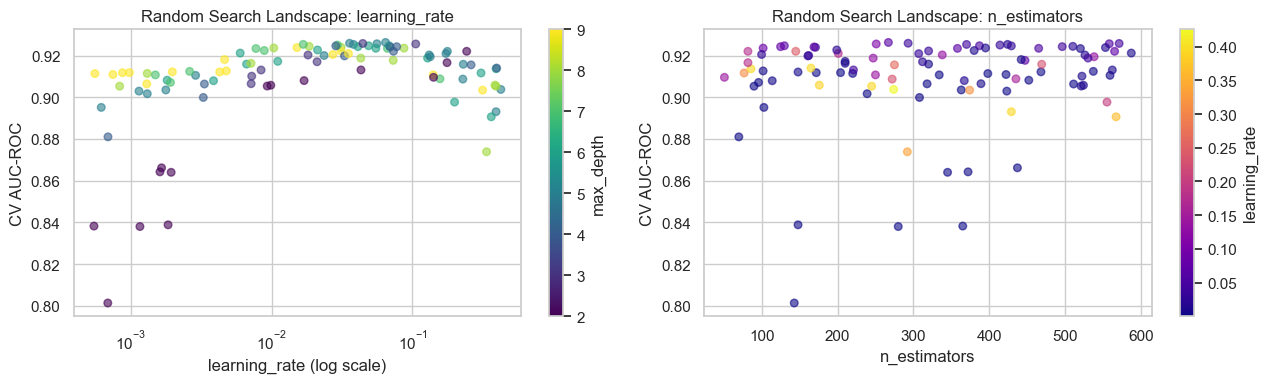

In [13]:
# ── Visualise the hyperparameter search landscape ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

results_df = pd.DataFrame(gs_phase1.cv_results_)

# learning_rate vs. AUC
axes[0].scatter(
    results_df["param_clf__learning_rate"].astype(float),
    results_df["mean_test_score"],
    c=results_df["param_clf__max_depth"].astype(int),
    cmap="viridis", alpha=0.6, s=30
)
axes[0].set_xscale("log")
axes[0].set_xlabel("learning_rate (log scale)")
axes[0].set_ylabel("CV AUC-ROC")
axes[0].set_title("Random Search Landscape: learning_rate")
sm = plt.cm.ScalarMappable(cmap="viridis",
    norm=plt.Normalize(vmin=2, vmax=9))
plt.colorbar(sm, ax=axes[0], label="max_depth")

# n_estimators vs. AUC
axes[1].scatter(
    results_df["param_clf__n_estimators"].astype(int),
    results_df["mean_test_score"],
    c=results_df["param_clf__learning_rate"].astype(float),
    cmap="plasma", alpha=0.6, s=30
)
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("CV AUC-ROC")
axes[1].set_title("Random Search Landscape: n_estimators")
sm2 = plt.cm.ScalarMappable(cmap="plasma",
    norm=plt.Normalize(
        vmin=results_df["param_clf__learning_rate"].astype(float).min(),
        vmax=results_df["param_clf__learning_rate"].astype(float).max()))
plt.colorbar(sm2, ax=axes[1], label="learning_rate")

plt.tight_layout()
plt.savefig(FIGURES / "ch16_search_landscape.png", dpi=150, bbox_inches="tight")
plt.show()

## Post-Tuning Model Finalisation

### Fitting the Final Model and Evaluating on the Test Set

In [12]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, f1_score, classification_report
)

# ── Refit best pipeline on full training set ─────────────────────────────
best_params = gs_phase2.best_params_

final_model = make_adult_pipe(
    GradientBoostingClassifier(
        learning_rate=best_params["clf__learning_rate"],
        max_depth=best_params["clf__max_depth"],
        n_estimators=best_params["clf__n_estimators"],
        subsample=best_params["clf__subsample"],
        random_state=RANDOM_SEED
    )
)
final_model.fit(X_atr, y_atr)   # full training set

y_pred_final  = final_model.predict(X_ate)
y_proba_final = final_model.predict_proba(X_ate)[:, 1]

print("=== Final Model Test Set Performance ===")
print(f"  Accuracy  : {accuracy_score(y_ate, y_pred_final):.4f}")
print(f"  F1 Score  : {f1_score(y_ate, y_pred_final):.4f}")
print(f"  AUC-ROC   : {roc_auc_score(y_ate, y_proba_final):.4f}")
print(f"  Avg Prec  : {average_precision_score(y_ate, y_proba_final):.4f}")
print(f"\nCV estimate (Phase 2): {gs_phase2.best_score_:.4f}")
print(f"Test AUC:              {roc_auc_score(y_ate, y_proba_final):.4f}")
print(f"CV–Test gap:           {gs_phase2.best_score_ - roc_auc_score(y_ate, y_proba_final):+.4f}")

=== Final Model Test Set Performance ===
  Accuracy  : 0.8772
  F1 Score  : 0.7245
  AUC-ROC   : 0.9311
  Avg Prec  : 0.8373

CV estimate (Phase 2): 0.9272
Test AUC:              0.9311
CV–Test gap:           -0.0039
